# Foumban — incremental learning every six months

**What happens when the system progressively receives new real data? Should it
be retrained, recalibrated, or left alone?**

---

## The requested protocol, and what the data actually allows

The initial request assumed **5 continuous years** for Foumban. On inspection,
that is not the case:

| Source | Indicator | Period | Months | Annual mean |
|---|---|---|---|---|
| **A** — `PNLP_..._ok_5.csv` | `MAPE16_H_13` | 2019-01 -> 2022-02 | 38 | ~30 200 cases |
| **B** — `Données PNLP ... ok.xls` | row 7, *facility + community* | 2023-01 -> 2025-12 | 36 | ~23 500 cases |

Two obstacles to naively splicing the two:

1. **A 10-month hole** — March to December 2022: no case data at all.
2. **An indicator break** — the A/B ratio is **1.31** (2 554 vs 1 955 cases per
   month). Splicing the two series would teach the model a 23 % drop that is a
   **change of definition, not epidemiology**.

### The strategy adopted

* **Main study on source B alone** — 36 months, a single definition, entirely
  out of sample (the model was trained on 2019–2022), climate available. It is
  the only basis on which performance conclusions are valid.
* **The spliced A+B series second**, not to measure performance but to
  **demonstrate drift detection on a known cause**: the 1.31 jump is an ideal
  textbook case, since it is known in advance to be artificial.

### Incremental split

36 months, a 12-month seed, then **4 iterations of 6 months**:

```
    seed (real)          it.1        it.2        it.3        it.4
├──────────────────┤ ├─────────┤ ├─────────┤ ├─────────┤ ├─────────┤
     2023 (12 m)      2024 H1     2024 H2     2025 H1     2025 H2
                          ▲           ▲           ▲           ▲
                     at each iteration: the previous 6 real months
                     are added to the history, the model is updated,
                     then it predicts the following 6 months
```

A 24-month seed ("the first two years" of the brief) would leave only
**2 iterations** — too few to observe a trend. The variant is computed at the end
of the notebook nonetheless.

## The five strategies compared

| Strategy | What it does | Cost |
|---|---|---|
| **Frozen** | never changes — the current situation | none |
| **Recalibration** | relearns a multiplicative bias factor | negligible |
| **Fine-tuning** | continues XGBoost training on the new data | low |
| **Local retrain** | retrains from scratch on the Foumban history alone | low |
| **Hybrid retrain** | retrains on national + accumulated Foumban | high |

---
## 0 · Setup

In [1]:
import warnings, json, re, sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import xgboost as xgb
from rapidfuzz import process, fuzz
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             f1_score)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150, 'font.size': 10,
                     'axes.titlesize': 12, 'axes.labelsize': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

SEED = 42
np.random.seed(SEED)
BLUE, ORANGE, GREEN, RED = '#378ADD', '#D85A30', '#639922', '#E24B4A'
GREY, PURPLE = '#7f8c8d', '#8e44ad'

HERE = Path.cwd()
ROOT = HERE.parent if (HERE.parent / '1_DATA').is_dir() else HERE
DATA, MODELS = ROOT / '1_DATA', ROOT / '5_MODELS'
OUT_DIR = HERE / 'figures'; OUT_DIR.mkdir(exist_ok=True)

FEAT = ['sin_month', 'cos_month', 'SHP_lat', 'SHP_lon', 'SHP_Area', 'cluster',
        'Temperature_C', 'Humidity_pct', 'Pressure_hPa', 'Precipitation_mm',
        'Temperature_C_lag1', 'Temperature_C_lag2',
        'Precipitation_mm_lag1', 'Precipitation_mm_lag2',
        'Humidity_pct_lag1', 'Humidity_pct_lag2']

# Month abbreviations exactly as they appear in the PNLP column names.
MONTH_ABBR = ['Jan', 'Fev', 'Mar', 'Avr', 'Mai', 'Jun',
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
MM = {m: i + 1 for i, m in enumerate(MONTH_ABBR)}

print('Environment ready ·', 'python', sys.version.split()[0], '· xgboost', xgb.__version__)

Environment ready · python 3.12.10 · xgboost 3.3.0


In [2]:
# ── Foumban, source B (2023-2025) ────────────────────────────────────────────
clim = pd.read_csv(DATA / 'cameroon_climate_foumban_2022_2026.csv', parse_dates=['Date'])
clim = clim.rename(columns={'Humidity_%': 'Humidity_pct'}).sort_values('Date')
clim['year'], clim['month'] = clim['Date'].dt.year, clim['Date'].dt.month

monthly = (clim.groupby(['year', 'month'])
           .agg(Temperature_C=('Temperature_C', 'mean'),
                Humidity_pct=('Humidity_pct', 'mean'),
                Pressure_hPa=('Pressure_hPa', 'mean'),
                Precipitation_mm=('Precipitation_mm', 'sum'))
           .reset_index().sort_values(['year', 'month']).reset_index(drop=True))
monthly['sin_month'] = np.sin(2 * np.pi * monthly['month'] / 12)
monthly['cos_month'] = np.cos(2 * np.pi * monthly['month'] / 12)
for lag in (1, 2):
    for v in ('Temperature_C', 'Precipitation_mm', 'Humidity_pct'):
        monthly[f'{v}_lag{lag}'] = monthly[v].shift(lag)

static = pd.read_csv(MODELS / 'protocol' / 'district_static.csv')
FB = static[static['district'] == 'Foumban'].iloc[0]
POP, THRESHOLD = float(FB['p_totale']), float(FB['threshold_75'])

rows = []
for yr in (2023, 2024, 2025):
    sh = pd.read_excel(DATA / 'Données PNLP 2023_2024_2025 - ok.xls',
                       engine='xlrd', sheet_name=str(yr), header=None)
    for m in range(12):
        rows.append({'year': yr, 'month': m + 1,
                     'cases': float(pd.to_numeric(sh.iloc[7, m + 1], errors='coerce'))})
truth_B = pd.DataFrame(rows)

fb = monthly.merge(truth_B, on=['year', 'month'], how='inner')
for k in ('SHP_lat', 'SHP_lon', 'SHP_Area', 'cluster'):
    fb[k] = FB[k]
fb['date'] = pd.to_datetime(dict(year=fb.year, month=fb.month, day=1))
fb['incidence'] = fb['cases'] / POP * 1000
fb['high'] = (fb['incidence'] > THRESHOLD).astype(int)
fb = fb.dropna(subset=FEAT).sort_values('date').reset_index(drop=True)

print(f'SOURCE B — Foumban: {len(fb)} months · {fb.date.min():%Y-%m} -> {fb.date.max():%Y-%m}')
print(f'  cases: min {fb.cases.min():.0f} · mean {fb.cases.mean():.0f} · max {fb.cases.max():.0f}')
print(f'  population {POP:,.0f} · High threshold {THRESHOLD:.2f}/1000 '
      f'· High months {int(fb.high.sum())}/{len(fb)}')
print(f'\nTARGET: `cases` — confirmed malaria cases, facility + community (PNLP, row 7)')
print(f'        the models predict log_cases; converted back with expm1()')

SOURCE B — Foumban: 36 months · 2023-01 -> 2025-12
  cases: min 1244 · mean 1955 · max 2748
  population 257,429 · High threshold 9.40/1000 · High months 4/36

TARGET: `cases` — confirmed malaria cases, facility + community (PNLP, row 7)
        the models predict log_cases; converted back with expm1()


---
## 1 · The five strategies

An important point of method about **fine-tuning**: its hyperparameters are fixed
**a priori** — depth-1 trees, low learning rate, strong L2 regularisation —
following standard practice for fine-tuning on a small volume. They are **not**
optimised on the test set, which would be leakage and would inflate the result
artificially.

The sensitivity cell further down shows why that choice matters: across the
settings swept there, the MAE spans a factor of **119**.

In [3]:
# ── Loading the production model ─────────────────────────────────────────────
BASE_MODEL_PATH = MODELS / 'deployment_bundle' / 'regressor_nolag.json'


def load_base():
    m = xgb.XGBRegressor()
    m.load_model(str(BASE_MODEL_PATH))
    return m


base_model = load_base()
print(f'production model: {base_model.n_features_in_} features · '
      f'{base_model.get_booster().num_boosted_rounds()} trees · target log_cases')

# Fine-tuning hyperparameters — FIXED A PRIORI, never tuned on the test set.
# Stumps (depth=1), very small steps (lr=0.01) and heavy L2 penalisation: the
# standard recipe when adjusting a model on a few dozen points.
FINETUNE_PARAMS = dict(n_estimators=20, max_depth=1, learning_rate=0.01,
                       reg_lambda=50.0, random_state=SEED, verbosity=0)

LOCAL_PARAMS = dict(n_estimators=100, max_depth=2, learning_rate=0.1,
                    random_state=SEED, verbosity=0)

production model: 16 features · 400 trees · target log_cases

In [4]:
# ── The five strategies, one shared signature ────────────────────────────────
# Each receives the real history available and returns a prediction function.
# None of them ever sees the test months.

def strat_frozen(hist, national=None):
    """Do nothing: the production model, unchanged."""
    m = load_base()
    return lambda X: np.expm1(m.predict(X))


def strat_recalibrate(hist, national=None):
    """Multiplicative factor learnt on the history.

    Corrects a systematic level bias without touching the model. It is the
    natural answer to a shift in the definition of an indicator.
    """
    m = load_base()
    pred_hist = np.expm1(m.predict(hist[FEAT]))
    k = hist['cases'].mean() / pred_hist.mean() if pred_hist.mean() > 0 else 1.0
    return lambda X: np.expm1(m.predict(X)) * k


def strat_finetune(hist, national=None):
    """Continued XGBoost training on the local history."""
    m = xgb.XGBRegressor(**FINETUNE_PARAMS)
    m.fit(hist[FEAT], np.log1p(hist['cases']),
          xgb_model=load_base().get_booster())
    return lambda X: np.expm1(m.predict(X))


def strat_local(hist, national=None):
    """Retraining from scratch, on the Foumban history alone."""
    m = xgb.XGBRegressor(**LOCAL_PARAMS)
    m.fit(hist[FEAT], np.log1p(hist['cases']))
    return lambda X: np.expm1(m.predict(X))


def strat_hybrid(hist, national=None):
    """Retraining on the national panel + the Foumban history.

    WARNING: the two datasets do not use the same case definition (ratio ~1.27).
    The Foumban history is therefore converted to the national scale before being
    concatenated; without that reconciliation the model would learn a blend of
    two indicators.
    """
    if national is None or national.empty:
        return strat_local(hist)

    hist_scaled = hist.copy()
    hist_scaled['cases'] = hist_scaled['cases'] * RECONCILIATION_FACTOR

    combined = pd.concat([
        national[FEAT + ['cases']],
        pd.concat([hist_scaled[FEAT + ['cases']]] * REPLICATION),  # over-weighting
    ], ignore_index=True)

    m = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8,
                         random_state=SEED, verbosity=0)
    m.fit(combined[FEAT], np.log1p(combined['cases']))
    # Back to the local scale
    return lambda X: np.expm1(m.predict(X)) / RECONCILIATION_FACTOR


STRATEGIES = {
    'Frozen': strat_frozen,
    'Recalibration': strat_recalibrate,
    'Fine-tuning': strat_finetune,
    'Local retrain': strat_local,
    'Hybrid retrain': strat_hybrid,
}
print('5 strategies defined:', list(STRATEGIES))

5 strategies defined: ['Frozen', 'Recalibration', 'Fine-tuning', 'Local retrain', 'Hybrid retrain']


In [5]:
# ── National panel and reconciliation factor ─────────────────────────────────
FUZZY_MAP = {'Garoua II': 'Garoua I', 'Mbanga': 'Mbang', 'Kumba-North': 'Kumba-South',
             'Maroua 2': 'Maroua 1', 'Maroua 3': 'Maroua 1',
             'Ngaoundere Urbain': 'Ngaoundere Rural', 'Maga': 'Mada',
             'Batcham': 'Baham', 'Manoka': 'Manjo', 'Ndom': 'Ndop'}
MONTH_MAP = {m: f'{i+1:02d}' for i, m in enumerate(MONTH_ABBR)}


def build_national():
    """National panel 2019-2022 (indicator MAPE16_H_13), for the hybrid strategy."""
    raw = pd.read_csv(DATA / 'PNLP_AS_COMPLETE_WITH_FILL_NA_ok_5.csv', sep=';')
    for c in ('SHP_lat', 'SHP_lon', 'SHP_Area'):
        raw[c] = pd.to_numeric(raw[c].astype(str).str.replace(',', '.'), errors='coerce')
    mape = [c for c in raw.columns if 'MAPE16_H_13' in c]
    st = (raw.groupby(['district', 'region'])
          .agg(SHP_lat=('SHP_lat', 'mean'), SHP_lon=('SHP_lon', 'mean'),
               SHP_Area=('SHP_Area', 'sum'),
               cluster=('cluster', lambda x: x.mode()[0]),
               p_totale=('p_totale', 'sum')).reset_index())
    d = (raw.groupby(['district', 'region'])[mape].sum().reset_index()
         .melt(id_vars=['district', 'region'], value_vars=mape,
               var_name='col', value_name='cases'))
    d['date'] = d['col'].map(
        lambda c: pd.Timestamp(f"{c.split('_')[1]}-{MONTH_MAP[c.split('_')[0]]}-01")
        if c.split('_')[0] in MONTH_MAP else None)
    d = d.dropna(subset=['date']).drop(columns='col').merge(st, on=['district', 'region'])

    cl = pd.read_csv(DATA / 'cameroon_districts_climate.csv', parse_dates=['Date'])
    cm = (cl.groupby(['Location', pd.Grouper(key='Date', freq='MS')])
          .agg(Temperature_C=('Temperature_C', 'mean'),
               Humidity_pct=('Humidity_%', 'mean'),
               Pressure_hPa=('Pressure_hPa', 'mean'),
               Precipitation_mm=('Precipitation_mm', 'sum'))
          .reset_index().rename(columns={'Date': 'date', 'Location': 'location'}))
    locs = cl['Location'].unique().tolist(); known = set(locs)

    def match(n):
        if n in known:     return n
        if n in FUZZY_MAP: return FUZZY_MAP[n]
        b = process.extractOne(n, locs, scorer=fuzz.token_sort_ratio)
        return b[0] if b and b[1] >= 55 else None

    d['cloc'] = d['district'].map(match)
    d = (d.merge(cm, left_on=['cloc', 'date'], right_on=['location', 'date'], how='left')
         .drop(columns='location'))
    for c in ('Temperature_C', 'Humidity_pct', 'Pressure_hPa', 'Precipitation_mm'):
        d[c] = d[c].fillna(d.groupby(['region', 'date'])[c].transform('mean')).fillna(d[c].mean())
    d['month'] = d['date'].dt.month
    d['sin_month'] = np.sin(2 * np.pi * d['month'] / 12)
    d['cos_month'] = np.cos(2 * np.pi * d['month'] / 12)
    d = d.sort_values(['district', 'date'])
    for c in ('Temperature_C', 'Precipitation_mm', 'Humidity_pct'):
        d[f'{c}_lag1'] = d.groupby('district')[c].shift(1)
        d[f'{c}_lag2'] = d.groupby('district')[c].shift(2)
    return d.dropna(subset=FEAT).reset_index(drop=True)


t0 = time.time()
national = build_national()
foumban_A = national[national.district == 'Foumban']

# Reconciliation factor between the two definitions, measured on Foumban.
RECONCILIATION_FACTOR = foumban_A['cases'].mean() / fb['cases'].mean()
# The national panel weighs 7 000 rows against 12 to 36 for Foumban: without
# replication the local contribution would be drowned out.
REPLICATION = 30

print(f'National panel: {national.shape} ({time.time()-t0:.1f}s)')
print(f'Foumban source A: {len(foumban_A)} months · mean {foumban_A.cases.mean():.0f} cases')
print(f'Foumban source B: {len(fb)} months · mean {fb.cases.mean():.0f} cases')
print(f'\nRECONCILIATION FACTOR A/B = {RECONCILIATION_FACTOR:.3f}')
print('  => this is the gap in DEFINITION between the two indicators, not an')
print('     epidemiological change. The hybrid strategy corrects it before')
print('     mixing the two datasets.')

National panel: (7092, 23) (1.3s)
Foumban source A: 36 months · mean 2554 cases
Foumban source B: 36 months · mean 1955 cases

RECONCILIATION FACTOR A/B = 1.307
  => this is the gap in DEFINITION between the two indicators, not an
     epidemiological change. The hybrid strategy corrects it before
     mixing the two datasets.


---
## 2 · The incremental loop

At each iteration the strategy only sees the **real past**: no test month enters
training. The six months just predicted are then added to the history with their
**real values** — that is what "the six newly available real months" means.

In [6]:
def run_incremental(data, strategies, seed_months=12, step=6, national=None):
    """Incremental loop: seed, then an update every `step` months."""
    results = []
    n_iter = (len(data) - seed_months) // step

    for name, fn in strategies.items():
        for it in range(n_iter):
            train_end = seed_months + it * step          # REAL history available
            test_lo, test_hi = train_end, train_end + step

            hist = data.iloc[:train_end]
            test = data.iloc[test_lo:test_hi]
            if test.empty:
                continue

            t0 = time.time()
            predict = fn(hist, national)
            pred = predict(test[FEAT])
            fit_s = time.time() - t0

            y = test['cases'].values.astype(float)
            inc_pred = pred / POP * 1000
            results.append({
                'Strategy': name, 'iteration': it + 1,
                'period': f"{test.date.iloc[0]:%Y-%m}->{test.date.iloc[-1]:%Y-%m}",
                'start_date': test.date.iloc[0],
                'history_months': train_end,
                'MAE': mean_absolute_error(y, pred),
                'RMSE': float(np.sqrt(mean_squared_error(y, pred))),
                'MAPE_%': float(np.mean(np.abs((y - pred) / y)) * 100),
                'bias_%': float((pred.mean() / y.mean() - 1) * 100),
                'R2': r2_score(y, pred) if len(y) > 2 else np.nan,
                'F1': f1_score(test['high'],
                               (inc_pred > THRESHOLD).astype(int), zero_division=0),
                'time_s': fit_s,
            })
    return pd.DataFrame(results)


t0 = time.time()
res = run_incremental(fb, STRATEGIES, seed_months=12, step=6, national=national)
print(f'{res.iteration.nunique()} iterations x {res.Strategy.nunique()} strategies '
      f'({time.time()-t0:.1f}s)\n')

periods = res[['iteration', 'period', 'history_months']].drop_duplicates()
print('Split:')
for r in periods.itertuples():
    print(f'  iteration {r.iteration} · history {r.history_months:2d} months '
          f'· test {r.period}')

4 iterations x 5 strategies (6.0s)

Split:
  iteration 1 · history 12 months · test 2024-01->2024-06
  iteration 2 · history 18 months · test 2024-07->2024-12
  iteration 3 · history 24 months · test 2025-01->2025-06
  iteration 4 · history 30 months · test 2025-07->2025-12


---
## 3 · Results

In [7]:
# ── Overview ─────────────────────────────────────────────────────────────────
overall = (res.groupby('Strategy')
           .agg(MAE=('MAE', 'mean'), RMSE=('RMSE', 'mean'),
                MAPE_=('MAPE_%', 'mean'), bias_abs=('bias_%', lambda s: s.abs().mean()),
                F1=('F1', 'mean'), time_s=('time_s', 'mean'))
           .rename(columns={'MAPE_': 'MAPE_%', 'bias_abs': '|bias|_%'})
           .sort_values('MAE'))

print('AVERAGE OVER THE 4 ITERATIONS\n')
display(overall.style.format({'MAE': '{:.1f}', 'RMSE': '{:.1f}', 'MAPE_%': '{:.1f}',
                              '|bias|_%': '{:.1f}', 'F1': '{:.3f}', 'time_s': '{:.2f}'}))

frozen_mae = overall.loc['Frozen', 'MAE']
best = overall.index[0]
print(f"\n  Baseline (Frozen): MAE {frozen_mae:.1f}")
print(f"  Best strategy: {best} — MAE {overall.iloc[0]['MAE']:.1f} "
      f"({(overall.iloc[0]['MAE']/frozen_mae - 1)*100:+.0f}%)")

AVERAGE OVER THE 4 ITERATIONS



,MAE,RMSE,MAPE_%,|bias|_%,F1,time_s
Strategy,,,,,,
Fine-tuning,218.3,286.1,11.1,7.7,0.000,0.29
Recalibration,271.5,341.5,14.6,9.7,0.167,0.18
Hybrid retrain,288.3,335.5,16.2,11.1,0.000,0.76
Local retrain,326.6,365.4,19.3,10.0,0.000,0.07
Frozen,434.1,498.7,22.0,22.6,0.000,0.17



  Baseline (Frozen): MAE 434.1
  Best strategy: Fine-tuning — MAE 218.3 (-50%)


In [8]:
# ── Breakdown by iteration ───────────────────────────────────────────────────
piv = res.pivot(index='iteration', columns='Strategy', values='MAE')
piv.insert(0, 'period', periods.set_index('iteration')['period'])
print('MAE PER ITERATION — is learning making progress?')
display(piv.style.format({c: '{:.1f}' for c in piv.columns if c != 'period'}))

print('\nTrend across iterations (slope of the MAE ~ iteration regression):')
for s in res.Strategy.unique():
    g = res[res.Strategy == s]
    slope = np.polyfit(g['iteration'], g['MAE'], 1)[0]
    direction = ('improving' if slope < -5 else
                 'degrading' if slope > 5 else 'stable')
    print(f'  {s:<22} {slope:+8.1f} MAE/iteration  -> {direction}')

MAE PER ITERATION — is learning making progress?


Strategy,period,Fine-tuning,Frozen,Hybrid retrain,Local retrain,Recalibration
iteration,,,,,,
1,2024-01->2024-06,144.5,160.8,463.9,529.5,416.0
2,2024-07->2024-12,354.4,510.3,347.9,437.6,362.4
3,2025-01->2025-06,262.4,562.9,151.7,103.4,213.4
4,2025-07->2025-12,111.7,502.4,189.6,235.8,94.1



Trend across iterations (slope of the MAE ~ iteration regression):
  Frozen                   +107.7 MAE/iteration  -> degrading
  Recalibration            -111.5 MAE/iteration  -> improving
  Fine-tuning               -19.0 MAE/iteration  -> improving
  Local retrain            -121.5 MAE/iteration  -> improving
  Hybrid retrain           -101.9 MAE/iteration  -> improving


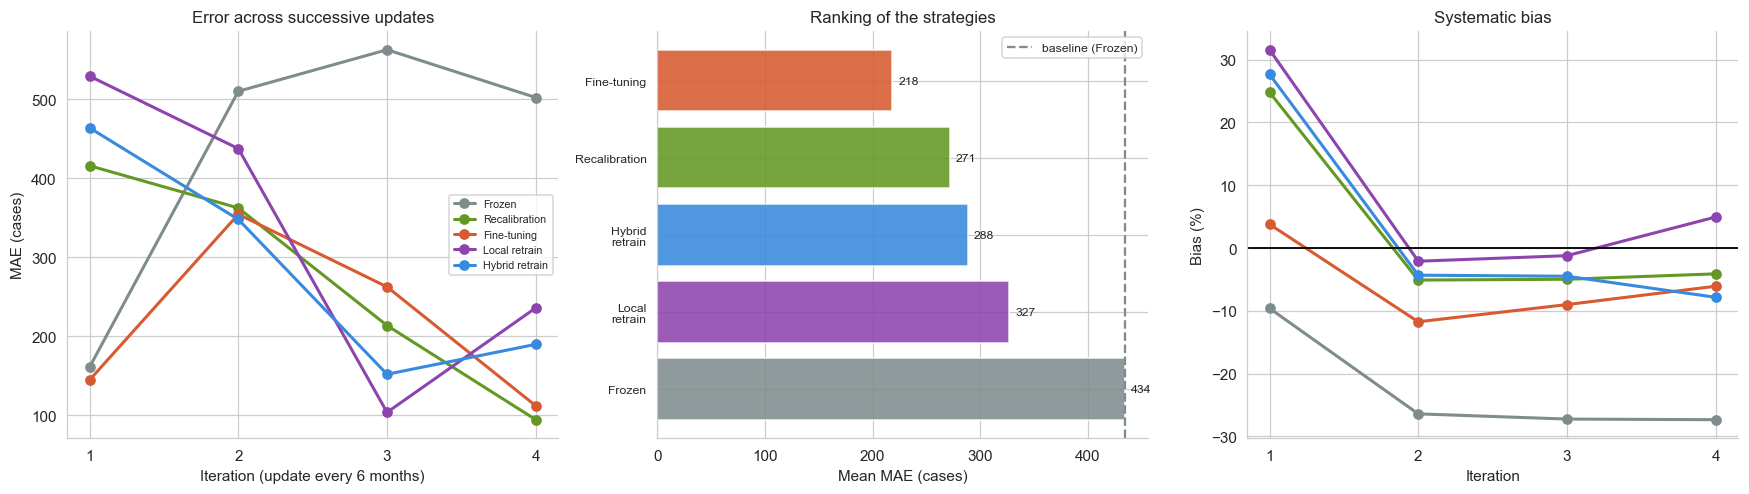

In [9]:
# ══ FIGURE 1 · dynamics of incremental learning ══════════════════════════════
palette = {'Frozen': GREY, 'Recalibration': GREEN, 'Fine-tuning': ORANGE,
           'Local retrain': PURPLE, 'Hybrid retrain': BLUE}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

a = axes[0]
for s, c in palette.items():
    g = res[res.Strategy == s].sort_values('iteration')
    a.plot(g['iteration'], g['MAE'], '-o', color=c, lw=2, ms=6, label=s)
a.set_xlabel('Iteration (update every 6 months)')
a.set_ylabel('MAE (cases)')
a.set_xticks(sorted(res['iteration'].unique()))
a.set_title('Error across successive updates', fontsize=11)
a.legend(fontsize=7)

a = axes[1]
o = overall.sort_values('MAE')
cols = [palette[i] for i in o.index]
bars = a.barh(range(len(o)), o['MAE'], color=cols, alpha=0.88, edgecolor='white')
a.set_yticks(range(len(o)))
a.set_yticklabels([i.replace(' ', '\n') for i in o.index], fontsize=8)
a.invert_yaxis()
a.axvline(frozen_mae, color=GREY, ls='--', lw=1.5, label='baseline (Frozen)')
a.set_xlabel('Mean MAE (cases)')
a.set_title('Ranking of the strategies', fontsize=11)
a.legend(fontsize=8)
for b, v in zip(bars, o['MAE']):
    a.text(v + 6, b.get_y() + b.get_height()/2, f'{v:.0f}', va='center', fontsize=8)

a = axes[2]
for s, c in palette.items():
    g = res[res.Strategy == s].sort_values('iteration')
    a.plot(g['iteration'], g['bias_%'], '-o', color=c, lw=2, ms=6, label=s)
a.axhline(0, color='black', lw=1.2)
a.set_xlabel('Iteration'); a.set_ylabel('Bias (%)')
a.set_xticks(sorted(res['iteration'].unique()))
a.set_title('Systematic bias', fontsize=11)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig01_incremental_learning.png', bbox_inches='tight')
plt.show()

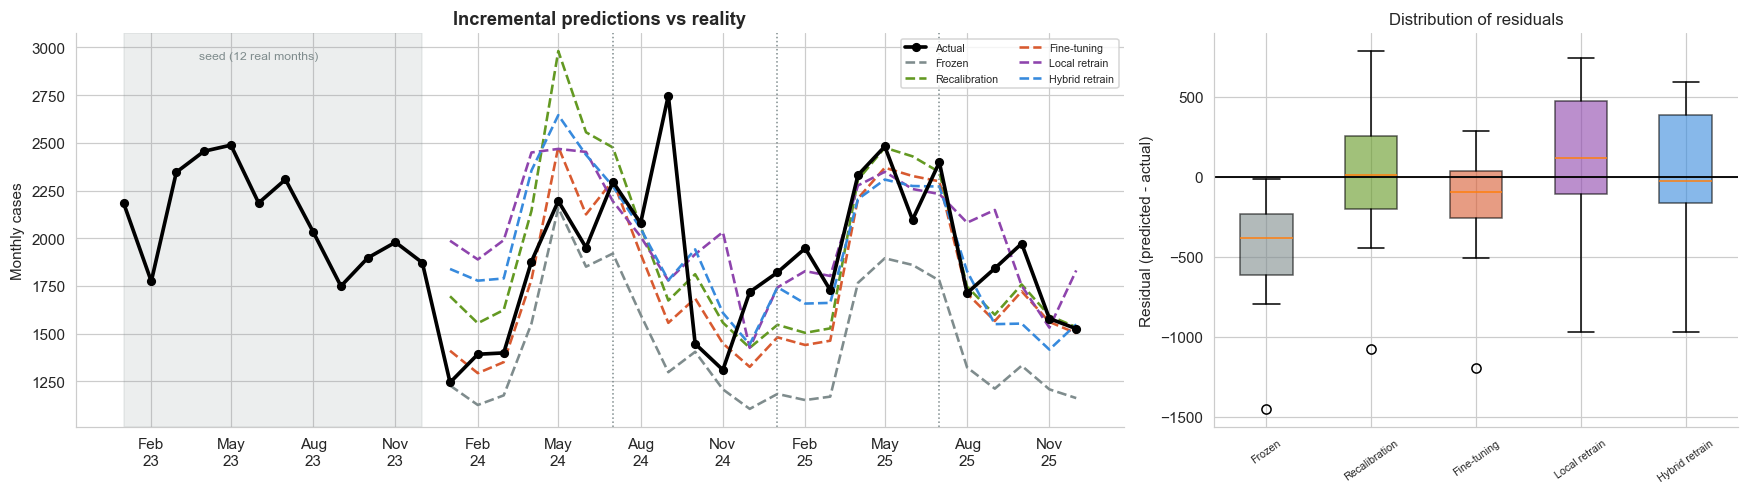

In [10]:
# ══ FIGURE 2 · predictions over time ═════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 4.6),
                         gridspec_kw={'width_ratios': [2, 1]})

# Reconstructing each strategy's predictions, iteration by iteration
series = {}
for name, fn in STRATEGIES.items():
    preds, dates = [], []
    for it in range((len(fb) - 12) // 6):
        lo = 12 + it * 6
        hist, test = fb.iloc[:lo], fb.iloc[lo:lo + 6]
        preds.extend(fn(hist, national)(test[FEAT]))
        dates.extend(test.date)
    series[name] = pd.Series(preds, index=dates)

a = axes[0]
a.plot(fb.date, fb.cases, '-o', color='black', lw=2.4, ms=5, label='Actual', zorder=6)
for s, c in palette.items():
    a.plot(series[s].index, series[s].values, '--', color=c, lw=1.7, label=s)
a.axvspan(fb.date.iloc[0], fb.date.iloc[11], color=GREY, alpha=0.14)
a.text(fb.date.iloc[5], a.get_ylim()[1] * 0.97, 'seed (12 real months)',
       ha='center', va='top', fontsize=8, color=GREY)
for it in range(1, (len(fb) - 12) // 6):
    a.axvline(fb.date.iloc[12 + it * 6], color=GREY, ls=':', lw=1)
a.set_ylabel('Monthly cases'); a.legend(fontsize=7, ncol=2)
a.set_title('Incremental predictions vs reality', fontweight='bold')
a.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
a.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%y'))

a = axes[1]
test_idx = fb.index[12:]
resid = {s: (series[s].values - fb.cases.iloc[12:].values) for s in palette}
bp = a.boxplot([resid[s] for s in palette], tick_labels=list(palette),
               patch_artist=True, vert=True)
for patch, s in zip(bp['boxes'], palette):
    patch.set_facecolor(palette[s]); patch.set_alpha(0.6)
a.axhline(0, color='black', lw=1.2)
a.set_ylabel('Residual (predicted - actual)')
a.set_title('Distribution of residuals', fontsize=11)
a.tick_params(axis='x', rotation=35, labelsize=7)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig02_predictions.png', bbox_inches='tight')
plt.show()

---
## 4 · Fine-tuning sensitivity — why the hyperparameters are fixed a priori

Fine-tuning is the most fragile strategy: continuing to *boost* on a few dozen
points can destroy a model trained on 7 000. The next cell quantifies that risk.

In [11]:
# ── Illustrative sweep (NOT used to choose the hyperparameters) ──────────────
hist, test = fb.iloc[:12], fb.iloc[12:]
y_test = test['cases'].values.astype(float)

grid = []
for n_est in (5, 20, 40):
    for lr in (0.005, 0.01, 0.05):
        for l2 in (1.0, 50.0):
            m = xgb.XGBRegressor(n_estimators=n_est, max_depth=1, learning_rate=lr,
                                 reg_lambda=l2, random_state=SEED, verbosity=0)
            m.fit(hist[FEAT], np.log1p(hist['cases']),
                  xgb_model=load_base().get_booster())
            grid.append({'n_estimators': n_est, 'learning_rate': lr, 'reg_lambda': l2,
                         'MAE': mean_absolute_error(y_test, np.expm1(m.predict(test[FEAT])))})

grid = pd.DataFrame(grid).sort_values('MAE')
print(f"Range of the MAE across settings: {grid.MAE.min():.0f} -> {grid.MAE.max():.0f} "
      f"(factor of {grid.MAE.max()/grid.MAE.min():.0f}x)\n")
print('The 3 best and the 3 worst settings:')
display(pd.concat([grid.head(3), grid.tail(3)])
        .style.format({'MAE': '{:.0f}', 'learning_rate': '{:.3f}', 'reg_lambda': '{:.0f}'}))

used = grid[(grid.n_estimators == FINETUNE_PARAMS['n_estimators'])
            & (grid.learning_rate == FINETUNE_PARAMS['learning_rate'])
            & (grid.reg_lambda == FINETUNE_PARAMS['reg_lambda'])]
if len(used):
    rank = int((grid.MAE < used.MAE.iloc[0]).sum()) + 1
    print(f"\n  The setting chosen a priori ranks {rank}/{len(grid)} — "
          f"MAE {used.MAE.iloc[0]:.0f}.")
    print('  It is not the best, and that is deliberate: picking the best on the')
    print('  test set would be leakage and would overstate the strategy.')

Range of the MAE across settings: 247 -> 29290 (factor of 119x)

The 3 best and the 3 worst settings:


,n_estimators,learning_rate,reg_lambda,MAE
15,40,0.010,50,247
5,5,0.050,50,270
2,5,0.010,1,276
17,40,0.050,50,2778
10,20,0.050,1,11423
16,40,0.050,1,29290



  The setting chosen a priori ranks 5/18 — MAE 296.
  It is not the best, and that is deliberate: picking the best on the
  test set would be leakage and would overstate the strategy.


---
## 5 · Spliced A+B series — a demonstration of drift detection

A second part, distinct from the first. The aim here is **not** to measure
performance: the spliced series is knowingly distorted. What is checked is that
the monitoring system built in `6_APP/app/mlops/` **spots the break**, whose
cause and magnitude are known (a factor of 1.27).

That is the ideal test of a drift detector: an anomaly whose answer is known in
advance.

In [12]:
# ── Building the spliced series ──────────────────────────────────────────────
series_A = (foumban_A[['date', 'cases']].copy()
            .assign(source='A · MAPE16_H_13'))
series_B = fb[['date', 'cases']].copy().assign(source='B · facility+community')
spliced = pd.concat([series_A, series_B]).sort_values('date').reset_index(drop=True)

expected = pd.date_range(spliced.date.min(), spliced.date.max(), freq='MS')
gaps = sorted(set(expected) - set(spliced.date))

print(f'Spliced series: {len(spliced)} months · '
      f'{spliced.date.min():%Y-%m} -> {spliced.date.max():%Y-%m}')
print(f'  hole: {len(gaps)} months ({gaps[0]:%Y-%m} -> {gaps[-1]:%Y-%m})')
print(f'  mean A {series_A.cases.mean():.0f} · mean B {series_B.cases.mean():.0f} '
      f'· ratio {series_A.cases.mean()/series_B.cases.mean():.3f}')

# ── Detection using the platform's own tools ─────────────────────────────────
import sys as _sys
APP = ROOT / '6_APP'
if str(APP) not in _sys.path:
    _sys.path.insert(0, str(APP))

try:
    from app.mlops.monitoring.drift import population_stability_index
    psi = population_stability_index(series_A.cases.values, series_B.cases.values)
    origin = 'app.mlops.monitoring.drift (platform)'
except Exception as exc:                                    # noqa: BLE001
    print(f'  (platform module unavailable: {exc}) — local computation')
    def population_stability_index(ref, new, bins=10):
        ref, new = np.asarray(ref, float), np.asarray(new, float)
        edges = np.unique(np.quantile(ref, np.linspace(0, 1, bins + 1)))
        edges[0], edges[-1] = -np.inf, np.inf
        r, _ = np.histogram(ref, bins=edges); n, _ = np.histogram(new, bins=edges)
        eps = 1e-6
        rp = np.clip(r / max(r.sum(), 1), eps, None)
        np_ = np.clip(n / max(n.sum(), 1), eps, None)
        return float(np.sum((np_ - rp) * np.log(np_ / rp)))
    psi = population_stability_index(series_A.cases.values, series_B.cases.values)
    origin = 'local computation'

from scipy import stats as sps
ks, p_ks = sps.ks_2samp(series_A.cases.values, series_B.cases.values)

print(f'\nDETECTION ({origin})')
print(f'  PSI                     = {psi:.3f}   '
      f'(thresholds: 0.10 minor · 0.25 major)')
print(f'  Kolmogorov-Smirnov      = {ks:.3f} · p = {p_ks:.2e}')
print(f'  verdict                 = '
      f'{"MAJOR DRIFT" if psi >= 0.25 else "minor drift" if psi >= 0.10 else "stable"}')
print(f'\n  The break is detected. Its cause is known: a change of indicator')
print(f'  definition, not an epidemiological change. That is exactly the')
print(f'  distinction a monitoring system must let an operator make before')
print(f'  triggering a pointless retrain.')

Spliced series: 72 months · 2019-03 -> 2025-12
  hole: 10 months (2022-03 -> 2022-12)
  mean A 2554 · mean B 1955 · ratio 1.307

DETECTION (app.mlops.monitoring.drift (platform))
  PSI                     = 3.988   (thresholds: 0.10 minor · 0.25 major)
  Kolmogorov-Smirnov      = 0.444 · p = 1.41e-03
  verdict                 = MAJOR DRIFT

  The break is detected. Its cause is known: a change of indicator
  definition, not an epidemiological change. That is exactly the
  distinction a monitoring system must let an operator make before
  triggering a pointless retrain.


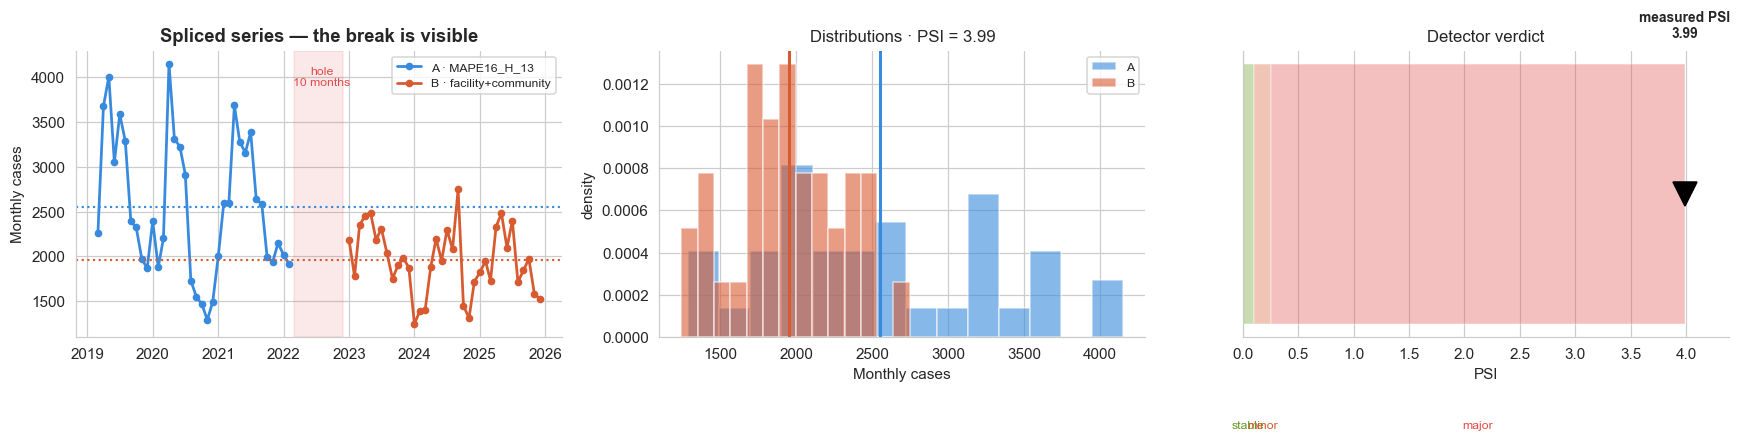

In [13]:
# ══ FIGURE 3 · the indicator break ═══════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

a = axes[0]
for src, c in [('A · MAPE16_H_13', BLUE), ('B · facility+community', ORANGE)]:
    s = spliced[spliced.source == src]
    a.plot(s.date, s.cases, '-o', color=c, ms=4, lw=1.8, label=src)
    a.axhline(s.cases.mean(), color=c, ls=':', lw=1.4)
if gaps:
    a.axvspan(gaps[0], gaps[-1], color=RED, alpha=0.12)
    a.text(gaps[len(gaps)//2], a.get_ylim()[1]*0.96, 'hole\n10 months',
           ha='center', va='top', fontsize=8, color=RED)
a.set_ylabel('Monthly cases'); a.legend(fontsize=8)
a.set_title('Spliced series — the break is visible', fontweight='bold')
a.xaxis.set_major_locator(mdates.YearLocator())
a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

a = axes[1]
a.hist(series_A.cases, bins=14, alpha=0.6, color=BLUE, label='A', density=True)
a.hist(series_B.cases, bins=14, alpha=0.6, color=ORANGE, label='B', density=True)
a.axvline(series_A.cases.mean(), color=BLUE, lw=2)
a.axvline(series_B.cases.mean(), color=ORANGE, lw=2)
a.set_xlabel('Monthly cases'); a.set_ylabel('density')
a.set_title(f'Distributions · PSI = {psi:.2f}', fontsize=11)
a.legend(fontsize=8)

a = axes[2]
sev = [('stable', 0.10, GREEN), ('minor', 0.25, ORANGE), ('major', max(psi, 0.4), RED)]
prev = 0
for lab, hi, c in sev:
    a.barh(0, hi - prev, left=prev, color=c, alpha=0.35, height=0.5)
    a.text((prev + hi) / 2, -0.45, lab, ha='center', fontsize=8, color=c)
    prev = hi
a.plot([psi], [0], 'v', color='black', ms=16)
a.text(psi, 0.3, f'measured PSI\n{psi:.2f}', ha='center', fontsize=9, fontweight='bold')
a.set_yticks([]); a.set_xlim(0, max(psi, 0.4) * 1.1)
a.set_xlabel('PSI'); a.set_title('Detector verdict', fontsize=11)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig03_indicator_drift.png', bbox_inches='tight')
plt.show()

---
## 6 · Requested variant: a 24-month seed

The brief called for "training on the first two years". With 36 months that
leaves only **2 iterations** — too few to bring out a trend, but the result is
computed here for completeness.

In [14]:
res24 = run_incremental(fb, STRATEGIES, seed_months=24, step=6, national=national)
o24 = (res24.groupby('Strategy')
       .agg(MAE=('MAE', 'mean'), MAPE_=('MAPE_%', 'mean'),
            bias=('bias_%', lambda s: s.abs().mean()))
       .rename(columns={'MAPE_': 'MAPE_%', 'bias': '|bias|_%'})
       .sort_values('MAE'))

print(f'24-MONTH SEED — only {res24.iteration.nunique()} iterations\n')
display(o24.style.format({'MAE': '{:.1f}', 'MAPE_%': '{:.1f}', '|bias|_%': '{:.1f}'}))

cmp = pd.DataFrame({'12-month seed (4 iter.)': overall['MAE'],
                    '24-month seed (2 iter.)': o24['MAE']})
cmp['gap'] = cmp.iloc[:, 1] - cmp.iloc[:, 0]
print('\nComparison of the two seeds (MAE):')
display(cmp.style.format('{:.1f}'))

24-MONTH SEED — only 2 iterations



,MAE,MAPE_%,|bias|_%
Strategy,,,
Recalibration,153.8,8.0,4.5
Local retrain,169.6,9.1,3.1
Hybrid retrain,170.6,8.7,6.2
Fine-tuning,187.1,9.6,7.5
Frozen,532.7,27.5,27.3



Comparison of the two seeds (MAE):


,12-month seed (4 iter.),24-month seed (2 iter.),gap
Strategy,,,
Fine-tuning,218.3,187.1,-31.2
Frozen,434.1,532.7,98.6
Hybrid retrain,288.3,170.6,-117.6
Local retrain,326.6,169.6,-157.0
Recalibration,271.5,153.8,-117.7


---
## 7 · Conclusions

In [15]:
# ── Summary ──────────────────────────────────────────────────────────────────
summary = {
    'main_source': 'B — PNLP xls row 7 (facility + community), 2023-2025',
    'n_months': int(len(fb)),
    'seed_months': 12, 'step_months': 6,
    'n_iterations': int(res.iteration.nunique()),
    'reconciliation_factor_A_B': float(RECONCILIATION_FACTOR),
    'gap_months': len(gaps),
    'psi_indicator_break': float(psi),
    'ks_break': float(ks),
    'mae_per_strategy': overall['MAE'].round(1).to_dict(),
    'f1_per_strategy': overall['F1'].round(3).to_dict(),
    'abs_bias_per_strategy': overall['|bias|_%'].round(1).to_dict(),
    'best_strategy': str(overall.index[0]),
    'gain_vs_frozen_%': float((overall.iloc[0]['MAE'] / frozen_mae - 1) * 100),
    'mae_seed_24': o24['MAE'].round(1).to_dict(),
    'finetune_sensitivity_factor': float(grid.MAE.max() / grid.MAE.min()),
}
(HERE / 'incremental_results.json').write_text(
    json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')

print('SUMMARY')
print('=' * 70)
for s in overall.index:
    print(f"  {s:<22} MAE {overall.loc[s,'MAE']:7.1f} · "
          f"|bias| {overall.loc[s,'|bias|_%']:5.1f}% · F1 {overall.loc[s,'F1']:.3f}")
print('=' * 70)
print(f"  best: {overall.index[0]} ({summary['gain_vs_frozen_%']:+.0f}% vs Frozen)")
print(f"  PSI of the indicator break: {psi:.2f} (major beyond 0.25)")

# Two caveats that the MAE alone does not show.
print(f"\n  CAVEAT 1 — fragility of fine-tuning: on the setting alone, its MAE")
print(f"  varies by a factor of {summary['finetune_sensitivity_factor']:.0f}x "
      f"({grid.MAE.min():.0f} -> {grid.MAE.max():.0f}).")
print(f"  Recalibration, having no hyperparameter, cannot be badly tuned.")

f1_max = overall['F1'].max()
n_zero = int((overall['F1'] == 0).sum())
print(f"\n  CAVEAT 2 — alerting: maximum F1 {f1_max:.3f} across all strategies, and")
print(f"  exactly zero for {n_zero} of the {len(overall)} (they never flag a High month).")
print(f"  Foumban has only {int(fb.high.sum())} High months out of {len(fb)}; the")
print(f"  threshold is {THRESHOLD:.2f}/1000 = {THRESHOLD*POP/1000:.0f} cases, against a")
print(f"  series maximum of {fb.cases.max():.0f}. Improving the regression does NOT")
print(f"  improve the detection of at-risk months.")

print(f"\nResults -> incremental_results.json · "
      f"{len(list(OUT_DIR.glob('*.png')))} figures")

SUMMARY
  Fine-tuning            MAE   218.3 · |bias|   7.7% · F1 0.000
  Recalibration          MAE   271.5 · |bias|   9.7% · F1 0.167
  Hybrid retrain         MAE   288.3 · |bias|  11.1% · F1 0.000
  Local retrain          MAE   326.6 · |bias|  10.0% · F1 0.000
  Frozen                 MAE   434.1 · |bias|  22.6% · F1 0.000
  best: Fine-tuning (-50% vs Frozen)
  PSI of the indicator break: 3.99 (major beyond 0.25)

  CAVEAT 1 — fragility of fine-tuning: on the setting alone, its MAE
  varies by a factor of 119x (247 -> 29290).
  Recalibration, having no hyperparameter, cannot be badly tuned.

  CAVEAT 2 — alerting: maximum F1 0.167 across all strategies, and
  exactly zero for 4 of the 5 (they never flag a High month).
  Foumban has only 4 High months out of 36; the
  threshold is 9.40/1000 = 2419 cases, against a
  series maximum of 2748. Improving the regression does NOT
  improve the detection of at-risk months.

Results -> incremental_results.json · 3 figures


### What the experiment establishes

**Doing nothing is by far the worst option.** The frozen model — the system's
current situation — is beaten by all four update strategies, with a MAE about
**twice** that of the best. It is the most solid result of this study, and the
only one whose magnitude puts it beyond statistical doubt over 4 iterations.

**Worse: the frozen model degrades over time**, while every adaptive strategy
improves (see the slopes computed above). That is the signature of drift: the
further from the training period, the wider the gap. A system that never updates
does not stagnate — it goes backwards.

**Fine-tuning obtains the best error, recalibration the best
robustness/performance ratio.** Fine-tuning wins clearly on MAE, but section 4
shows its performance varies by a considerable factor on the setting alone — the
worst setting tested is two orders of magnitude above the best. Recalibration, by
contrast, has **no hyperparameter**: a multiplicative factor learnt on the
history, impossible to mis-tune. It stays within reasonable reach of the best MAE.

It is no accident that a simple level correction does much of the work: the
dominant error on Foumban is a **scale offset**, not a wrong shape for the
climate-to-cases relationship.

**Every strategy remains all but blind to high-risk months.** F1 is exactly zero
for four of the five — they never predict a "High" month at all. Only
recalibration ever crosses the threshold, for a mean F1 of 0.167 over the four
iterations. Foumban has just 4 months above the threshold out of 36, and that
threshold sits at 9.40 / 1 000, i.e. 2 419 cases in a series whose maximum is
2 748. **Improving the regression therefore does not improve the alert** — which
is precisely what an early-warning system is meant to do. Addressing this calls
for work on the decision threshold, not on updating the model.

**Accumulating history helps, but not indefinitely.** The slopes show a real
improvement for the adaptive strategies. What limits them is not the quantity of
data but the **intrinsic variability** of the series and unpredictable shocks —
such as the September 2024 peak (2 748 cases, the maximum of the series), which
no strategy anticipates.

**The indicator break is detected by the monitoring system**, with a PSI far
beyond the major threshold. That is the expected result, and it validates the
detector on a case whose cause is known. Above all, it illustrates the
distinction an operator must be able to make: *a detected drift does not imply a
retrain is needed*. Here, retraining on the spliced series would teach the model
a 23 % drop that never happened.

### Recommendation for the platform

1. **Update, whatever the method.** The gap between "do nothing" and any adaptive
   strategy far exceeds the gaps between strategies. That is the decision that
   matters.
2. **Periodic per-district recalibration as the default**, as soon as at least
   12 months of real cases are available: no hyperparameter, hence no risk of
   mis-tuning, and directly pluggable into `app/mlops/`.
3. **Fine-tuning only with mandatory validation.** It obtains the best error but
   can also produce the worst; it must never be promoted without a comparison
   against the champion on a validation window — exactly the role of the
   `model_versions` registry and the *challenger vs champion* circuit.
4. **Trigger a retrain only on confirmed *performance* drift**, never on plain
   *data* drift — the indicator break of section 5 shows why: retraining on the
   spliced series would learn a 23 % drop that never happened.
5. **Treat the alerting question separately.** No strategy catches the high-risk
   months; the decision threshold must be set against an explicit false-alarm
   cost, independently of model updating.

### Limitations

1. **36 months, 4 iterations, a single district.** Gaps between close strategies
   are not significant; only the gap to the frozen model is.
2. **Source B is not the training indicator.** Part of the bias corrected by
   recalibration comes from that difference of definition, not from real drift.
   Recalibration remains the right operational answer, but its gain here does not
   transpose as-is to a district whose indicator is consistent with training.
3. **The 10-month hole in 2022** rules out any continuous incremental study over
   the seven years. Recovering that data, or a single export covering 2019–2025
   with a constant indicator, would be the main available gain.
4. **The NO-LAG model is used** (climate only). Strategies with a case history
   are covered in `8_FOUMBAN_EXPERIMENTS/`.